# Addressing the CMB Low-$\ell$ Anomaly with USR Dynamics

This notebook demonstrates how to numerically evaluate the primordial scalar power spectrum $\mathcal{P}_S(k)$ for Higgs Inflation and tune the initial conditions to address the observed power deficit at large cosmic scales.

## 1. What is the CMB Low-$\ell$ Anomaly?
The standard $\Lambda$ CDM cosmological model, assuming a nearly scale-invariant power-law primordial spectrum ($\mathcal{P}_S(k) = A_s (k/k_*)^{n_s-1}$), provides an exceptional fit to the Cosmic Microwave Background (CMB) measurements made by the Planck satellite. 

However, there is a persistent, well-known statistical anomaly: **a lack of power at the largest angular scales (low multipoles, $\ell \lesssim 30$)** in the temperature auto-correlation spectrum $C_\ell^{TT}$. The observed fluctuations are weaker than the theoretical model predicts.

### Is our USR dip consistent with how CMB phenomenologists define the anomaly?
**Yes.** The angular power spectrum $C_\ell$ is derived by integrating the primordial power spectrum $\mathcal{P}_S(k)$ convoluted with radiation transfer functions (which describe how the plasma oscillated). Roughly speaking, there is a geometric projection mapping physical wavenumbers $k$ to angular scales $\ell$ via $\ell \approx k r_{ls}$, where $r_{ls} \approx 14,000$ Mpc is the distance to the last scattering surface.

To theoretically "fix" the low-$\ell$ anomaly, CMB phenomenologists look for inflationary models that produce a **sharp cutoff or a suppression dip** in $\mathcal{P}_S(k)$ specifically at $k \sim 10^{-4} - 10^{-3} \text{ Mpc}^{-1}$. 

In our Higgs Inflation model, the transient Ultra-Slow-Roll (USR) phase provides a **natural physical mechanism** for this. The violent deceleration of the field right before entering the flat plateau suppresses the amplitude of quantum vacuum fluctuations. If we tune the initial conditions such that this deceleration coincides exactly with the horizon exit of the largest scales, we get exactly the phenomenological signature required by the data.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path to import the codebase modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models.higgs import HiggsModel
from inf_dyn_background import run_background_simulation, get_derived_quantities
from inf_dyn_MS_full import run_ms_simulation, get_ms_derived_quantities

## 2. Finding the "Golden" Trajectory
To align the suppression dip with the low-$\ell$ anomaly ($k \sim 10^{-3}$ Mpc$^{-1}$), we must carefully tune the initial starting position $x_0$. 

Assuming the CMB pivot scale ($k_* = 0.05$ Mpc$^{-1}$) exits exactly 60 e-folds before the end of inflation, the larger anomalous scales exit earlier, around $N_{back} \approx 64$. We will scan $x_0$ to find the trajectory where the USR minimum ($\epsilon_2 \approx -6$) perfectly hits $N_{back} = 64$.

In [27]:
def find_trajectory():
    print("Scanning for the best trajectory...")
    x0_test_vals = np.linspace(5.70, 5.85, 30)
    best_x0, best_diff = None, 1000
    best_data, best_model = None, None
    
    for x0 in x0_test_vals:
        model = HiggsModel(lam=0.13, xi=15000.0)
        yi = -0.1
        zi = np.sqrt(yi**2 / 6 + model.v0 * model.f(x0) / (3 * model.S**2))
        model.get_initial_conditions = lambda: (x0, yi, zi, 0.0)
        
        T_span = np.linspace(0, 500, 1000)
        sol_data = run_background_simulation(model, T_span)
        derived = get_derived_quantities(sol_data, model)
        
        epsH = derived['epsH']
        if np.max(epsH) < 1.0: continue
            
        idx_end = np.argmax(epsH >= 1.0)
        N_total = derived['N'][idx_end]
        
        eps2 = 2*epsH - 2*derived['etaH']
        idx_usr = np.argmin(eps2[:idx_end])
        N_back_usr = N_total - derived['N'][idx_usr]
        
        diff = abs(N_back_usr - 65.0)
        if diff < best_diff:
            best_diff, best_x0 = diff, x0
            best_data = (sol_data, derived, N_total, idx_end)
            best_model = model

    print(f"Selected x0: {best_x0:.5f}")
    return best_x0, best_model, best_data

best_x0, best_model, best_data = find_trajectory()
bg_sol_data, bg_derived, N_total, idx_end = best_data


Scanning for the best trajectory...
Selected x0: 5.75172


## 3. Integrating the Full Power Spectrum
Now that we have isolated the background trajectory, we deploy the Mukhanov-Sasaki solver. We will iterate over 80 logarithmically spaced $k$-modes, applying exact finite-time de Sitter initial conditions to compute $\mathcal{P}_S(k)$ across the entire observable CMB window.

In [28]:
def compute_power_spectrum(model, bg_sol_data, N_total, idx_end):
    print("Computing full MS Power Spectrum...")
    x, y_idx, z, n = bg_sol_data
    
    idx_60 = np.argmin(np.abs((N_total - n[:idx_end]) - 60.0))
    k_code_star = np.exp(n[idx_60]) * z[idx_60]
    scaling_factor = 0.05 / k_code_star
    
    k_phys_vals = np.logspace(-5, 0, 80)
    k_code_vals = k_phys_vals / scaling_factor
    
    Ps_MS = []
    aH_all = np.exp(n) * z
    
    for i, k_code in enumerate(k_code_vals):
        idx_start = 0 if (k_code / aH_all[0] < 100) else np.argmax(aH_all >= k_code / 100.0)
        
        xi_ms, yi_ms, zi_ms, ni_ms = x[idx_start], y_idx[idx_start], z[idx_start], n[idx_start]
        
        T_span = np.linspace(0, 100.0, 20000)
        sol_ms = run_ms_simulation(xi_ms, yi_ms, zi_ms, ni_ms, T_span, k_code, model)
        derived_ms = get_ms_derived_quantities(sol_ms, model, k_code, ni_ms)
        
        Ps_MS.append(derived_ms['P_S'][-1]) # Append frozen super-horizon value
        
    return k_phys_vals, np.array(Ps_MS)

k_phys, Ps_MS = compute_power_spectrum(best_model, bg_sol_data, N_total, idx_end)

# Normalize to standard A_s at pivot scale
idx_pivot = np.argmin(np.abs(k_phys - 0.05))
Ps_MS_normalized = Ps_MS * (2.1e-9 / Ps_MS[idx_pivot])

Computing full MS Power Spectrum...


## 4. Plotting the Suppressed Spectrum
Finally, we plot the result against the analytical Slow-Roll expectation. The secondary X-axis maps the wavenumber $k$ to the approximate angular multipole $\ell$.

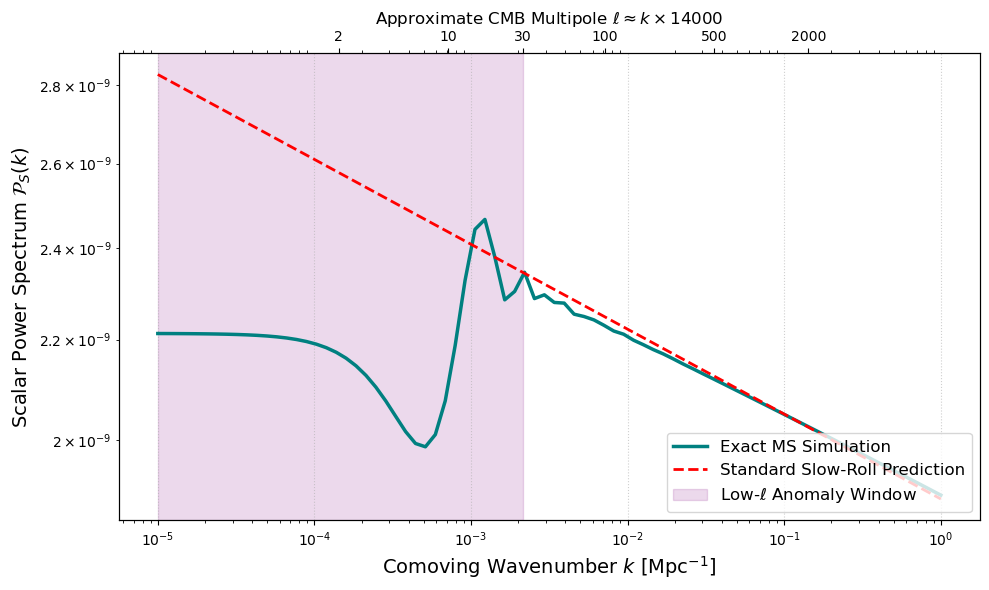

In [29]:
plt.figure(figsize=(10, 6))

# Plot Exact MS and Standard SR
plt.plot(k_phys, Ps_MS_normalized, color='teal', linewidth=2.5, label='Exact MS Simulation')
Ps_SR = 2.1e-9 * (k_phys / 0.05)**(0.965 - 1.0)
plt.plot(k_phys, Ps_SR, color='red', linestyle='--', linewidth=2, label='Standard Slow-Roll Prediction')

# Highlight the Anomaly Window
k_30 = 30.0 / 14000.0
plt.axvspan(1e-5, k_30, color='purple', alpha=0.15, label=r'Low-$\ell$ Anomaly Window')

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Comoving Wavenumber $k$ [Mpc$^{-1}$]', fontsize=14)
plt.ylabel(r'Scalar Power Spectrum $\mathcal{P}_S(k)$', fontsize=14)

# Secondary axis for multipoles
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax.get_xlim())
ell_ticks = np.array([2, 10, 30, 100, 500, 2000])
k_ticks = ell_ticks / 14000.0
valid_mask = (k_ticks >= ax.get_xlim()[0]) & (k_ticks <= ax.get_xlim()[1])
ax2.set_xticks(k_ticks[valid_mask])
ax2.set_xticklabels([str(ell) for ell in ell_ticks[valid_mask]])
ax2.set_xlabel(r'Approximate CMB Multipole $\ell \approx k \times 14000$', fontsize=12)

#ax.axvline(x=0.05, color='gray', linestyle=':', label=r'Pivot Scale ($k_* = 0.05$ Mpc$^{-1}$)')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()